In [1]:
!pip install fuzzywuzzy
!pip install geopy
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import re


In [7]:
print("Step 1: Load cleaned datasets")
dc_osdc_clean = pd.read_csv('/Users/zdiener/data-center-classification/data/processed/osdc_cleaned.csv')
dc_frac_clean = pd.read_csv('/Users/zdiener/data-center-classification/data/processed/fractracker_cleaned.csv')

Step 1: Load cleaned datasets


In [18]:
# Cell: Enhanced Name Matching Functions

import re
from fuzzywuzzy import fuzz

def clean_name_for_matching(name):
    """
    Clean facility name for better matching by removing common noise words
    """
    if pd.isna(name):
        return ""
    
    name = str(name).lower().strip()
    
    # Remove common data center variations
    data_center_patterns = [
        r'\bdata center\b',
        r'\bdata centre\b',
        r'\bdatacenter\b',
        r'\bdc\b',
        r'\bdata hall\b',
        r'\bserver farm\b',
        r'\bserver facility\b',
    ]
    
    for pattern in data_center_patterns:
        name = re.sub(pattern, '', name, flags=re.IGNORECASE)
    
    # Remove common corporate suffixes
    corp_patterns = [
        r'\bllc\b',
        r'\binc\b',
        r'\bcorp\b',
        r'\bcorporation\b',
        r'\bltd\b',
        r'\blimited\b',
        r'\bco\b',
        r'\bcompany\b',
    ]
    
    for pattern in corp_patterns:
        name = re.sub(pattern, '', name, flags=re.IGNORECASE)
    
    # Remove special characters and extra whitespace
    name = re.sub(r'[^\w\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name


def extract_location_context(row, is_osdc=True):
    """
    Extract location identifiers from the row
    """
    if is_osdc:
        location_parts = [
            str(row.get('name', '')),
            str(row.get('operator', '')),
            str(row.get('county', '')),
            str(row.get('state_abb', ''))
        ]
    else:  # FracTracker
        location_parts = [
            str(row.get('facility_name', '')),
            str(row.get('operator_name', '')),
            str(row.get('city', '')),
            str(row.get('county', '')),
            str(row.get('state_abb', ''))
        ]
    
    # Filter out 'nan' and empty strings
    location_parts = [p for p in location_parts if p and p != 'nan']
    
    return ' '.join(location_parts).lower()


def calculate_enhanced_name_similarity(osdc_row, frac_row):
    """
    Calculate similarity using multiple strategies and take the best
    
    Returns dict with different similarity scores
    """
    # Strategy 1: Clean names only (excludes "data center")
    osdc_clean = clean_name_for_matching(osdc_row.get('name', ''))
    frac_clean = clean_name_for_matching(frac_row.get('facility_name', ''))
    
    name_only_score = fuzz.token_sort_ratio(osdc_clean, frac_clean)
    
    # Strategy 2: Name + Operator
    osdc_with_operator = f"{osdc_clean} {clean_name_for_matching(osdc_row.get('operator', ''))}"
    frac_with_operator = f"{frac_clean} {clean_name_for_matching(frac_row.get('operator_name', ''))}"
    
    name_operator_score = fuzz.token_sort_ratio(osdc_with_operator, frac_with_operator)
    
    # Strategy 3: Full location context (name + operator + location)
    osdc_context = extract_location_context(osdc_row, is_osdc=True)
    frac_context = extract_location_context(frac_row, is_osdc=False)
    
    full_context_score = fuzz.token_sort_ratio(osdc_context, frac_context)
    
    # Strategy 4: Partial ratio (good for catching substrings)
    partial_score = fuzz.partial_ratio(osdc_clean, frac_clean)
    
    # Strategy 5: Check for operator match
    osdc_operator = clean_name_for_matching(osdc_row.get('operator', ''))
    frac_operator = clean_name_for_matching(frac_row.get('operator_name', ''))
    operator_match_score = fuzz.token_sort_ratio(osdc_operator, frac_operator) if osdc_operator and frac_operator else 0
    
    # Strategy 6: City/County match boost
    location_boost = 0
    osdc_county = str(osdc_row.get('county', '')).lower()
    frac_county = str(frac_row.get('county', '')).lower()
    frac_city = str(frac_row.get('city', '')).lower()
    
    if osdc_county and frac_county:
        if fuzz.ratio(osdc_county, frac_county) > 80:
            location_boost = 20
    if osdc_county and frac_city:
        if fuzz.ratio(osdc_county, frac_city) > 80:
            location_boost = max(location_boost, 15)
    
    # Take the maximum score from all strategies
    best_score = max(
        name_only_score,
        name_operator_score,
        full_context_score,
        partial_score,
        operator_match_score
    )
    
    # Apply location boost
    final_score = min(100, best_score + location_boost)
    
    return {
        'name_only': name_only_score,
        'name_operator': name_operator_score,
        'full_context': full_context_score,
        'partial': partial_score,
        'operator_match': operator_match_score,
        'location_boost': location_boost,
        'best_score': best_score,
        'final_score': final_score,
        'osdc_clean': osdc_clean,
        'frac_clean': frac_clean
    }


print("✓ Enhanced matching functions loaded!")

✓ Enhanced matching functions loaded!


In [19]:
# Cell: Smart Matching with Enhanced Name Comparison

def smart_match_datacenters_enhanced(dc_osdc, dc_frac, 
                                     osdc_lat='latitude', osdc_lon='longitude',
                                     frac_lat='latitude', frac_lon='longitude'):
    """
    Enhanced matching with better name comparison
    """
    
    print("="*60)
    print("ENHANCED SMART MATCHING WITH IMPROVED NAME COMPARISON")
    print("="*60)
    
    # Calculate density for both datasets
    print("\n1. Analyzing state density patterns...")
    osdc_density = calculate_state_density(dc_osdc, 'state_abb')
    frac_density = calculate_state_density(dc_frac, 'state_abb')
    
    print(f"\nOSDC State Distribution:")
    for category in ['single', 'sparse', 'moderate', 'dense']:
        states = [s for s, c in osdc_density.items() if c == category]
        print(f"   {category.capitalize():12}: {len(states)} states")
    
    print(f"\nFracTracker State Distribution:")
    for category in ['single', 'sparse', 'moderate', 'dense']:
        states = [s for s, c in frac_density.items() if c == category]
        print(f"   {category.capitalize():12}: {len(states)} states")
    
    # Adaptive matching thresholds
    matching_rules = {
        'single': {
            'distance_km': None,
            'name_threshold': 0,
            'description': 'Only one facility in state - auto-match'
        },
        'sparse': {
            'distance_km': 50,
            'name_threshold': 50,  # Increased from 40
            'description': 'Few facilities - loose matching'
        },
        'moderate': {
            'distance_km': 5,
            'name_threshold': 65,  # Increased from 60
            'description': 'Moderate density - balanced matching'
        },
        'dense': {
            'distance_km': 1,
            'name_threshold': 75,  # Decreased from 80 since we have better matching
            'description': 'Many facilities - strict matching'
        }
    }
    
    print("\n2. Matching rules (with enhanced name comparison):")
    for category, rules in matching_rules.items():
        print(f"\n   {category.upper()}:")
        print(f"      Distance: {rules['distance_km']}km" if rules['distance_km'] else "      Distance: Any")
        print(f"      Name similarity: >{rules['name_threshold']}%")
        print(f"      ({rules['description']})")
    
    # Perform matching
    print("\n3. Matching facilities with enhanced algorithm...")
    matches = []
    
    for idx_osdc, row_osdc in tqdm(dc_osdc.iterrows(), total=len(dc_osdc), desc="Matching"):
        state = row_osdc['state_abb']
        
        # Determine matching strategy
        density_category = osdc_density.get(state, 'moderate')
        rules = matching_rules[density_category]
        
        # Filter FracTracker to same state
        same_state_frac = dc_frac[dc_frac['state_abb'] == state]
        
        if len(same_state_frac) == 0:
            matches.append({
                'osdc_idx': idx_osdc,
                'frac_idx': None,
                'match_type': 'osdc_only',
                'distance_m': None,
                'name_similarity': 0,
                'state_density': density_category,
                'composite_score': 0,
                'matching_strategy': None
            })
            continue
        
        # Special case: single facility in state
        if density_category == 'single' and len(same_state_frac) == 1:
            frac_idx = same_state_frac.index[0]
            distance = geodesic(
                (row_osdc[osdc_lat], row_osdc[osdc_lon]),
                (same_state_frac.loc[frac_idx, frac_lat], same_state_frac.loc[frac_idx, frac_lon])
            ).meters
            
            # Use enhanced name matching
            name_scores = calculate_enhanced_name_similarity(row_osdc, same_state_frac.loc[frac_idx])
            
            matches.append({
                'osdc_idx': idx_osdc,
                'frac_idx': frac_idx,
                'match_type': 'auto_single',
                'distance_m': distance,
                'name_similarity': name_scores['final_score'],
                'state_density': density_category,
                'composite_score': 100,
                'matching_strategy': 'single_state',
                'name_details': name_scores
            })
            continue
        
        # Find best match
        best_match = None
        best_score = -1
        
        for idx_frac, row_frac in same_state_frac.iterrows():
            # Calculate distance
            distance = geodesic(
                (row_osdc[osdc_lat], row_osdc[osdc_lon]),
                (row_frac[frac_lat], row_frac[frac_lon])
            ).meters
            
            # Enhanced name similarity
            name_scores = calculate_enhanced_name_similarity(row_osdc, row_frac)
            name_sim = name_scores['final_score']
            
            # Check thresholds
            distance_ok = (rules['distance_km'] is None or 
                          distance <= rules['distance_km'] * 1000)
            name_ok = name_sim >= rules['name_threshold']
            
            if distance_ok and name_ok:
                # Calculate composite score
                if rules['distance_km']:
                    distance_score = max(0, 100 - (distance / (rules['distance_km'] * 1000)) * 100)
                else:
                    distance_score = 100
                
                composite_score = (distance_score * 0.5) + (name_sim * 0.5)  # Equal weight
                
                if composite_score > best_score:
                    best_score = composite_score
                    best_match = {
                        'osdc_idx': idx_osdc,
                        'frac_idx': idx_frac,
                        'match_type': 'matched',
                        'distance_m': distance,
                        'name_similarity': name_sim,
                        'state_density': density_category,
                        'composite_score': composite_score,
                        'matching_strategy': name_scores.get('best_score', 'unknown'),
                        'name_details': name_scores
                    }
        
        if best_match:
            matches.append(best_match)
        else:
            matches.append({
                'osdc_idx': idx_osdc,
                'frac_idx': None,
                'match_type': 'osdc_only',
                'distance_m': None,
                'name_similarity': 0,
                'state_density': density_category,
                'composite_score': 0,
                'matching_strategy': None
            })
    
    matches_df = pd.DataFrame(matches)
    
    # Summary
    print("\n4. Matching results by state density:")
    for category in ['single', 'sparse', 'moderate', 'dense']:
        category_matches = matches_df[matches_df['state_density'] == category]
        if len(category_matches) > 0:
            matched_count = (category_matches['match_type'].isin(['matched', 'auto_single'])).sum()
            print(f"\n   {category.upper()}:")
            print(f"      Total OSDC facilities: {len(category_matches)}")
            print(f"      Matched: {matched_count} ({matched_count/len(category_matches)*100:.1f}%)")
            print(f"      Unmatched: {len(category_matches) - matched_count}")
            
            if matched_count > 0:
                matched_subset = category_matches[category_matches['match_type'].isin(['matched', 'auto_single'])]
                print(f"      Avg distance: {matched_subset['distance_m'].mean()/1000:.2f}km")
                print(f"      Avg name similarity: {matched_subset['name_similarity'].mean():.1f}%")
    
    return matches_df


print("✓ Enhanced matching function loaded!")

✓ Enhanced matching function loaded!


In [20]:
# Cell: Test the enhanced name matching on sample pairs

print("="*60)
print("TESTING ENHANCED NAME MATCHING")
print("="*60)

# Test on some example pairs
test_pairs = [
    {
        'osdc': {'name': 'Google Data Center', 'operator': 'Google', 'county': 'Douglas County'},
        'frac': {'facility_name': 'Google Data Center Council Bluffs', 'operator_name': 'Google', 
                'city': 'Council Bluffs', 'county': 'Pottawattamie County'}
    },
    {
        'osdc': {'name': 'Microsoft Azure', 'operator': 'Microsoft', 'county': 'Polk County'},
        'frac': {'facility_name': 'Project Alluvion', 'operator_name': 'Microsoft', 
                'city': 'Des Moines', 'county': 'Polk County'}
    },
    {
        'osdc': {'name': 'Apple Prineville Datacenter', 'operator': 'Apple', 'county': 'Crook County'},
        'frac': {'facility_name': 'Apple DC Prineville', 'operator_name': 'Apple', 
                'city': 'Prineville', 'county': 'Crook County'}
    },
]

for i, pair in enumerate(test_pairs):
    print(f"\nTest Pair {i+1}:")
    print(f"  OSDC: {pair['osdc']['name']} ({pair['osdc'].get('operator', 'N/A')})")
    print(f"  Frac: {pair['frac']['facility_name']} ({pair['frac'].get('operator_name', 'N/A')})")
    
    # Create mock row objects
    osdc_row = pd.Series(pair['osdc'])
    frac_row = pd.Series(pair['frac'])
    
    scores = calculate_enhanced_name_similarity(osdc_row, frac_row)
    
    print(f"\n  Scores:")
    print(f"    Name only (no 'data center'): {scores['name_only']}")
    print(f"    Name + Operator: {scores['name_operator']}")
    print(f"    Full context: {scores['full_context']}")
    print(f"    Partial match: {scores['partial']}")
    print(f"    Operator match: {scores['operator_match']}")
    print(f"    Location boost: {scores['location_boost']}")
    print(f"    → FINAL SCORE: {scores['final_score']}")
    print(f"\n  Cleaned strings:")
    print(f"    OSDC: '{scores['osdc_clean']}'")
    print(f"    Frac: '{scores['frac_clean']}'")

TESTING ENHANCED NAME MATCHING

Test Pair 1:
  OSDC: Google Data Center (Google)
  Frac: Google Data Center Council Bluffs (Google)

  Scores:
    Name only (no 'data center'): 44
    Name + Operator: 63
    Full context: 55
    Partial match: 100
    Operator match: 100
    Location boost: 0
    → FINAL SCORE: 100

  Cleaned strings:
    OSDC: 'google'
    Frac: 'google council bluffs'

Test Pair 2:
  OSDC: Microsoft Azure (Microsoft)
  Frac: Project Alluvion (Microsoft)

  Scores:
    Name only (no 'data center'): 39
    Name + Operator: 63
    Full context: 65
    Partial match: 40
    Operator match: 100
    Location boost: 20
    → FINAL SCORE: 100

  Cleaned strings:
    OSDC: 'microsoft azure'
    Frac: 'project alluvion'

Test Pair 3:
  OSDC: Apple Prineville Datacenter (Apple)
  Frac: Apple DC Prineville (Apple)

  Scores:
    Name only (no 'data center'): 100
    Name + Operator: 100
    Full context: 80
    Partial match: 100
    Operator match: 100
    Location boost: 20
  

In [21]:
# Cell: Run enhanced matching on full datasets

print("Running enhanced matching on cleaned datasets...\n")

# Run enhanced matching
matches_df_enhanced = smart_match_datacenters_enhanced(
    dc_osdc_clean, 
    dc_frac_clean,
    osdc_lat='latitude',
    osdc_lon='longitude',
    frac_lat='latitude',
    frac_lon='longitude'
)

# Create combined dataset using the same function as before
dc_combined_enhanced = create_combined_dataset(dc_osdc_clean, dc_frac_clean, matches_df_enhanced)

# Save results
output_path = '/Users/zdiener/data-center-classification/data/processed/datacenters_combined_enhanced.csv'
dc_combined_enhanced.to_csv(output_path, index=False)
print(f"\n✓ Enhanced combined dataset saved to: {output_path}")

matches_path = '/Users/zdiener/data-center-classification/data/processed/matching_results_enhanced.csv'
matches_df_enhanced.to_csv(matches_path, index=False)
print(f"✓ Enhanced match details saved to: {matches_path}")

Running enhanced matching on cleaned datasets...

ENHANCED SMART MATCHING WITH IMPROVED NAME COMPARISON

1. Analyzing state density patterns...

OSDC State Distribution:
   Single      : 7 states
   Sparse      : 10 states
   Moderate    : 16 states
   Dense       : 13 states

FracTracker State Distribution:
   Single      : 7 states
   Sparse      : 6 states
   Moderate    : 24 states
   Dense       : 13 states

2. Matching rules (with enhanced name comparison):

   SINGLE:
      Distance: Any
      Name similarity: >0%
      (Only one facility in state - auto-match)

   SPARSE:
      Distance: 50km
      Name similarity: >50%
      (Few facilities - loose matching)

   MODERATE:
      Distance: 5km
      Name similarity: >65%
      (Moderate density - balanced matching)

   DENSE:
      Distance: 1km
      Name similarity: >75%
      (Many facilities - strict matching)

3. Matching facilities with enhanced algorithm...


Matching:   0%|          | 0/1242 [00:00<?, ?it/s]


4. Matching results by state density:

   SINGLE:
      Total OSDC facilities: 7
      Matched: 5 (71.4%)
      Unmatched: 2
      Avg distance: 229.32km
      Avg name similarity: 54.2%

   SPARSE:
      Total OSDC facilities: 31
      Matched: 14 (45.2%)
      Unmatched: 17
      Avg distance: 21.91km
      Avg name similarity: 64.4%

   MODERATE:
      Total OSDC facilities: 204
      Matched: 42 (20.6%)
      Unmatched: 162
      Avg distance: 0.73km
      Avg name similarity: 95.0%

   DENSE:
      Total OSDC facilities: 1000
      Matched: 304 (30.4%)
      Unmatched: 696
      Avg distance: 0.27km
      Avg name similarity: 95.5%

5. Creating combined dataset...

   Adding 1294 unmatched FracTracker facilities

   Final combined dataset: 2536 facilities
   - OSDC primary: 1242
   - With FracTracker match: 365
   - FracTracker supplemental: 1294

✓ Enhanced combined dataset saved to: /Users/zdiener/data-center-classification/data/processed/datacenters_combined_enhanced.csv
✓ Enh

In [22]:
# Cell: Compare original vs enhanced matching

print("="*60)
print("COMPARISON: Original vs Enhanced Matching")
print("="*60)

# Show improvement in matches
matched_enhanced = matches_df_enhanced[matches_df_enhanced['match_type'].isin(['matched', 'auto_single'])]

print(f"\nEnhanced Matching Results:")
print(f"  Total matches: {len(matched_enhanced)}")
print(f"  Average name similarity: {matched_enhanced['name_similarity'].mean():.1f}%")
print(f"  Matches with >80% similarity: {(matched_enhanced['name_similarity'] > 80).sum()}")
print(f"  Matches with >90% similarity: {(matched_enhanced['name_similarity'] > 90).sum()}")

# Show examples where enhanced matching made a difference
print(f"\n{'='*60}")
print("SAMPLE HIGH-QUALITY MATCHES")
print(f"{'='*60}")

high_quality = matched_enhanced[matched_enhanced['name_similarity'] > 85].head(10)

for _, match in high_quality.iterrows():
    osdc_row = dc_osdc_clean.loc[match['osdc_idx']]
    frac_row = dc_frac_clean.loc[match['frac_idx']]
    
    print(f"\n{osdc_row['state_abb']} | Distance: {match['distance_m']/1000:.2f}km | Similarity: {match['name_similarity']:.0f}%")
    print(f"  OSDC: {osdc_row['name']}")
    print(f"  Frac: {frac_row['facility_name']}")
    if 'name_details' in match and isinstance(match['name_details'], dict):
        details = match['name_details']
        print(f"  Cleaned: '{details['osdc_clean']}' ↔ '{details['frac_clean']}'")

COMPARISON: Original vs Enhanced Matching

Enhanced Matching Results:
  Total matches: 365
  Average name similarity: 93.7%
  Matches with >80% similarity: 309
  Matches with >90% similarity: 276

SAMPLE HIGH-QUALITY MATCHES

NC | Distance: 0.18km | Similarity: 100%
  OSDC: Google Data Center
  Frac: Google Data Center
  Cleaned: 'google' ↔ 'google'

IA | Distance: 0.11km | Similarity: 100%
  OSDC: Project Alluvion
  Frac: Project Alluvion (Microsoft)
  Cleaned: 'project alluvion' ↔ 'project alluvion microsoft'

NC | Distance: 0.27km | Similarity: 100%
  OSDC: Apple - Maiden Data Center
  Frac: Apple Data Center
  Cleaned: 'apple maiden' ↔ 'apple'

VA | Distance: 0.10km | Similarity: 100%
  OSDC: Meta Henrico Data Center
  Frac: 6200 TECHNOLOGY BLVD
  Cleaned: 'meta henrico' ↔ '6200 technology blvd'

AL | Distance: 0.40km | Similarity: 100%
  OSDC: Meta Huntsville Data Center
  Frac: Meta Data Center
  Cleaned: 'meta huntsville' ↔ 'meta'

CA | Distance: 0.96km | Similarity: 100%
  OSDC

In [23]:
# Cell: Analyze Unmatched FracTracker Records by Status

print("="*60)
print("UNMATCHED FRACTRACKER ANALYSIS")
print("="*60)

# Get unmatched FracTracker indices
matched_frac_indices = matches_df_enhanced['frac_idx'].dropna().unique()
unmatched_frac = dc_frac_clean[~dc_frac_clean.index.isin(matched_frac_indices)]

print(f"\nTotal FracTracker records: {len(dc_frac_clean)}")
print(f"Matched to OSDC: {len(matched_frac_indices)}")
print(f"Unmatched: {len(unmatched_frac)}")

# Analyze by status
print(f"\n{'='*60}")
print("UNMATCHED FRACTRACKER RECORDS BY STATUS")
print(f"{'='*60}")

status_breakdown = unmatched_frac['status'].value_counts()
print(f"\n{status_breakdown}")

# Show detailed breakdown
print(f"\n{'='*60}")
print("DETAILED STATUS ANALYSIS")
print(f"{'='*60}")

# Group statuses into categories
operational_keywords = ['operating', 'operational', 'active']
proposed_keywords = ['proposed', 'planned', 'under construction', 'approved', 'permitted']
cancelled_keywords = ['cancelled', 'canceled', 'suspended', 'paused', 'denied']

def categorize_status(status):
    if pd.isna(status):
        return 'Unknown'
    status_lower = str(status).lower()
    
    if any(keyword in status_lower for keyword in operational_keywords):
        return 'Operational'
    elif any(keyword in status_lower for keyword in proposed_keywords):
        return 'Proposed/Planned'
    elif any(keyword in status_lower for keyword in cancelled_keywords):
        return 'Cancelled/Suspended'
    else:
        return 'Other'

unmatched_frac['status_category'] = unmatched_frac['status'].apply(categorize_status)

print("\nStatus Categories:")
print(unmatched_frac['status_category'].value_counts())

# Calculate adjusted match rate
print(f"\n{'='*60}")
print("ADJUSTED MATCH RATE CALCULATION")
print(f"{'='*60}")

# Count operational FracTracker facilities
operational_frac = dc_frac_clean[dc_frac_clean['status'].apply(categorize_status) == 'Operational']
proposed_frac = dc_frac_clean[dc_frac_clean['status'].apply(categorize_status) == 'Proposed/Planned']
cancelled_frac = dc_frac_clean[dc_frac_clean['status'].apply(categorize_status) == 'Cancelled/Suspended']

print(f"\nFracTracker Breakdown:")
print(f"  Total facilities: {len(dc_frac_clean)}")
print(f"  Operational: {len(operational_frac)}")
print(f"  Proposed/Planned: {len(proposed_frac)}")
print(f"  Cancelled/Suspended: {len(cancelled_frac)}")
print(f"  Other/Unknown: {len(dc_frac_clean) - len(operational_frac) - len(proposed_frac) - len(cancelled_frac)}")

# Calculate match rate against operational only
matched_count = len(matched_frac_indices)
operational_match_rate = (matched_count / len(operational_frac) * 100) if len(operational_frac) > 0 else 0

print(f"\nMatch Rates:")
print(f"  Raw match rate: {matched_count}/{len(dc_frac_clean)} = {matched_count/len(dc_frac_clean)*100:.1f}%")
print(f"  Adjusted match rate (operational only): {matched_count}/{len(operational_frac)} = {operational_match_rate:.1f}%")

# How many operational FracTracker are unmatched?
unmatched_operational = unmatched_frac[unmatched_frac['status_category'] == 'Operational']
print(f"\n  Unmatched operational facilities: {len(unmatched_operational)}")
print(f"  These may be missing from OSDC or have quality issues")

UNMATCHED FRACTRACKER ANALYSIS

Total FracTracker records: 1492
Matched to OSDC: 198
Unmatched: 1294

UNMATCHED FRACTRACKER RECORDS BY STATUS

status
Proposed                                 657
Operating                                383
Approved/Permitted/Under construction    123
Suspended                                 47
Cancelled                                 46
Expanding                                 37
Unknown                                    1
Name: count, dtype: int64

DETAILED STATUS ANALYSIS

Status Categories:
status_category
Proposed/Planned       780
Operational            383
Cancelled/Suspended     93
Other                   38
Name: count, dtype: int64

ADJUSTED MATCH RATE CALCULATION

FracTracker Breakdown:
  Total facilities: 1492
  Operational: 529
  Proposed/Planned: 815
  Cancelled/Suspended: 95
  Other/Unknown: 53

Match Rates:
  Raw match rate: 198/1492 = 13.3%
  Adjusted match rate (operational only): 198/529 = 37.4%

  Unmatched operational facilities

In [24]:
# Cell: Examine Unmatched Operational Facilities

print("="*60)
print("UNMATCHED OPERATIONAL FACILITIES (Potential Missing Data)")
print("="*60)

unmatched_operational = unmatched_frac[unmatched_frac['status_category'] == 'Operational']

if len(unmatched_operational) > 0:
    print(f"\nFound {len(unmatched_operational)} operational facilities in FracTracker not matched to OSDC")
    print("\nThese facilities are operating but not in OSDC dataset:\n")
    
    # Show by state
    print("By State:")
    print(unmatched_operational['state_abb'].value_counts().head(15))
    
    # Show details of top unmatched operational facilities
    print(f"\n{'='*60}")
    print("Sample Unmatched Operational Facilities:")
    print(f"{'='*60}\n")
    
    display_cols = ['facility_name', 'operator_name', 'city', 'state_abb', 'status', 
                    'mw_numeric', 'facility_size_sqft_numeric']
    display_cols = [col for col in display_cols if col in unmatched_operational.columns]
    
    for idx, row in unmatched_operational.head(20).iterrows():
        print(f"{row['state_abb']:3} | {row['facility_name'][:50]:50}")
        if pd.notna(row.get('operator_name')):
            print(f"      Operator: {row['operator_name']}")
        if pd.notna(row.get('city')):
            print(f"      Location: {row['city']}, {row['county']}")
        if pd.notna(row.get('mw_numeric')):
            print(f"      Power: {row['mw_numeric']} MW")
        print()
else:
    print("\n✓ All operational FracTracker facilities are matched to OSDC!")

UNMATCHED OPERATIONAL FACILITIES (Potential Missing Data)

Found 383 operational facilities in FracTracker not matched to OSDC

These facilities are operating but not in OSDC dataset:

By State:
state_abb
VA    123
GA     71
TX     46
PA     38
NY     15
OH     13
WA      9
CA      6
IN      6
NE      5
AZ      4
ND      4
NJ      4
NM      4
CO      3
Name: count, dtype: int64

Sample Unmatched Operational Facilities:

AL  | DC Blox                                           
      Location: Birmingham, Jefferson

AL  | DC Blox                                           
      Location: Huntsville, Madison

AR  | Data center                                       
      Operator: Windstream
      Location: Harrison, Boone

AR  | Brightspeed Data Center                           
      Location: Russellville, Pope

AZ  | Expedient Data Center                             
      Operator: Expedient
      Location: Phoenix, Maricopa
      Power: 2.0 MW

AZ  | PHX1                            

In [25]:
# Cell: Create Filtered Match Rate Report

print("="*60)
print("FINAL MATCH RATE REPORT")
print("="*60)

# Categorize all FracTracker records
dc_frac_clean['status_category'] = dc_frac_clean['status'].apply(categorize_status)

# Get operational subset
frac_operational = dc_frac_clean[dc_frac_clean['status_category'] == 'Operational']
frac_proposed = dc_frac_clean[dc_frac_clean['status_category'] == 'Proposed/Planned']
frac_cancelled = dc_frac_clean[dc_frac_clean['status_category'] == 'Cancelled/Suspended']

# Count matched operational facilities
matched_frac_operational = frac_operational[frac_operational.index.isin(matched_frac_indices)]

print(f"\nDATASET SUMMARY:")
print(f"  OSDC facilities: {len(dc_osdc_clean)}")
print(f"  FracTracker total: {len(dc_frac_clean)}")
print(f"    - Operational: {len(frac_operational)}")
print(f"    - Proposed/Planned: {len(frac_proposed)}")
print(f"    - Cancelled/Suspended: {len(frac_cancelled)}")
print(f"    - Other/Unknown: {len(dc_frac_clean) - len(frac_operational) - len(frac_proposed) - len(frac_cancelled)}")

print(f"\nMATCHING RESULTS:")
print(f"  OSDC facilities matched: {(matches_df_enhanced['match_type'] != 'osdc_only').sum()}/{len(dc_osdc_clean)} ({(matches_df_enhanced['match_type'] != 'osdc_only').sum()/len(dc_osdc_clean)*100:.1f}%)")
print(f"  FracTracker matched: {len(matched_frac_indices)}/{len(dc_frac_clean)} ({len(matched_frac_indices)/len(dc_frac_clean)*100:.1f}%)")

print(f"\nADJUSTED MATCHING (Operational FracTracker Only):")
print(f"  FracTracker operational matched: {len(matched_frac_operational)}/{len(frac_operational)} ({len(matched_frac_operational)/len(frac_operational)*100:.1f}%)")
print(f"  FracTracker operational unmatched: {len(frac_operational) - len(matched_frac_operational)}")

print(f"\nEXPECTED UNMATCHED (Non-operational):")
print(f"  Proposed/Planned: {len(frac_proposed)}")
print(f"  Cancelled/Suspended: {len(frac_cancelled)}")

# Calculate true match rate (excluding proposed/cancelled)
true_matchable = len(frac_operational)
true_matched = len(matched_frac_operational)
true_match_rate = (true_matched / true_matchable * 100) if true_matchable > 0 else 0

print(f"\n{'='*60}")
print(f"TRUE MATCH RATE: {true_match_rate:.1f}%")
print(f"({true_matched} operational facilities matched out of {true_matchable})")
print(f"{'='*60}")

# Identify gap: operational but unmatched
gap = len(frac_operational) - len(matched_frac_operational)
if gap > 0:
    print(f"\n⚠️  {gap} operational FracTracker facilities not found in OSDC")
    print(f"   These may represent:")
    print(f"   - Facilities not yet added to OSDC")
    print(f"   - Different naming conventions preventing match")
    print(f"   - Geocoding errors in one dataset")

FINAL MATCH RATE REPORT

DATASET SUMMARY:
  OSDC facilities: 1242
  FracTracker total: 1492
    - Operational: 529
    - Proposed/Planned: 815
    - Cancelled/Suspended: 95
    - Other/Unknown: 53

MATCHING RESULTS:
  OSDC facilities matched: 365/1242 (29.4%)
  FracTracker matched: 198/1492 (13.3%)

ADJUSTED MATCHING (Operational FracTracker Only):
  FracTracker operational matched: 146/529 (27.6%)
  FracTracker operational unmatched: 383

EXPECTED UNMATCHED (Non-operational):
  Proposed/Planned: 815
  Cancelled/Suspended: 95

TRUE MATCH RATE: 27.6%
(146 operational facilities matched out of 529)

⚠️  383 operational FracTracker facilities not found in OSDC
   These may represent:
   - Facilities not yet added to OSDC
   - Different naming conventions preventing match
   - Geocoding errors in one dataset


In [26]:
# Cell: Finalize Combined Dataset with All Records

print("="*60)
print("FINALIZING COMBINED DATASET")
print("="*60)

# Use the enhanced combined dataset we created
dc_combined_final = dc_combined_enhanced.copy()

# Ensure all OSDC records are tagged as operational
dc_combined_final.loc[dc_combined_final['source'] == 'osdc_primary', 'is_operational'] = True
dc_combined_final.loc[dc_combined_final['source'] == 'osdc_primary', 'frac_status_category'] = 'Operational (OSDC)'

# Fill NaN status for OSDC-only records
dc_combined_final['frac_status'] = dc_combined_final['frac_status'].fillna('Operating')

print(f"\nFinal Dataset Summary:")
print(f"  Total facilities: {len(dc_combined_final)}")
print(f"  OSDC primary (all operational): {(dc_combined_final['source'] == 'osdc_primary').sum()}")
print(f"  FracTracker supplemental: {(dc_combined_final['source'] == 'frac_supplemental').sum()}")
print(f"  OSDC with FracTracker match: {dc_combined_final['frac_idx'].notna().sum()}")

print(f"\nStatus breakdown:")
status_counts = dc_combined_final['frac_status_category'].fillna('Operational (OSDC)').value_counts()
print(status_counts)

# Ensure coordinate columns are properly named
if 'lon' in dc_combined_final.columns and 'longitude' not in dc_combined_final.columns:
    dc_combined_final = dc_combined_final.rename(columns={'lon': 'longitude'})
if 'lat' in dc_combined_final.columns and 'latitude' not in dc_combined_final.columns:
    dc_combined_final = dc_combined_final.rename(columns={'lat': 'latitude'})

# Check for any missing coordinates
missing_coords = dc_combined_final['latitude'].isna() | dc_combined_final['longitude'].isna()
if missing_coords.any():
    print(f"\n⚠️  WARNING: {missing_coords.sum()} records have missing coordinates")
    print(dc_combined_final[missing_coords][['name', 'frac_facility_name', 'state_abb', 'source']])

print(f"\n✓ Dataset ready for census tract geocoding")
print(f"  Records with valid coordinates: {(~missing_coords).sum()}")

# Save final pre-geocoding dataset
output_path = '/Users/zdiener/data-center-classification/data/processed/datacenters_combined_final.csv'
dc_combined_final.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

FINALIZING COMBINED DATASET

Final Dataset Summary:
  Total facilities: 2536
  OSDC primary (all operational): 1242
  FracTracker supplemental: 1294
  OSDC with FracTracker match: 365

Status breakdown:
frac_status_category
Operational (OSDC)    2536
Name: count, dtype: int64

✓ Dataset ready for census tract geocoding
  Records with valid coordinates: 2536

✓ Saved to: /Users/zdiener/data-center-classification/data/processed/datacenters_combined_final.csv


convert to census tract (AI GENERATED)

In [32]:
# Cell: Download census tracts from correct source

import geopandas as gpd
from shapely.geometry import Point
import requests
import zipfile
import os

print("Downloading 2020 Census Tract boundaries...")

# Correct URL for nationwide census tracts
# We'll use the cartographic boundary file (smaller, faster)
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_tract_500k.zip"

# Download to a local file
local_zip = '/Users/zdiener/data-center-classification/data/raw/census_tracts.zip'
local_extract = '/Users/zdiener/data-center-classification/data/raw/census_tracts/'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(local_zip), exist_ok=True)
os.makedirs(local_extract, exist_ok=True)

# Download the file
print("Downloading shapefile (this may take a minute)...")
response = requests.get(url, stream=True)
response.raise_for_status()

with open(local_zip, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("✓ Downloaded")

# Extract
print("Extracting...")
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall(local_extract)

print("✓ Extracted")

# Load shapefile
print("Loading census tracts...")
tracts = gpd.read_file(local_extract)
print(f"✓ Loaded {len(tracts)} census tracts")

# Show sample
print(f"\nSample tract data:")
print(tracts[['GEOID', 'STATEFP', 'COUNTYFP', 'TRACTCE']].head())

✓ Downloaded
Extracting...
✓ Extracted
Loading census tracts...
✓ Loaded 85187 census tracts

Sample tract data:
         GEOID STATEFP COUNTYFP TRACTCE
0  06077003406      06      077  003406
1  06077004402      06      077  004402
2  06077004600      06      077  004600
3  06077001400      06      077  001400
4  06077003106      06      077  003106


In [34]:
# Cell: Load EJScreen 2024 Tract Data

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import zipfile

print("="*60)
print("LOADING EJSCREEN 2024 TRACT DATA")
print("="*60)

# Path to your downloaded EJScreen data
ejscreen_zip = '/Users/zdiener/data-center-classification/data/raw/EJScreen_2024_Tract_StatePct_with_AS_CNMI_GU_VI.csv.zip'

# Read directly from zip file
print("\nLoading EJScreen 2024 tract-level data...")
ejscreen = pd.read_csv(ejscreen_zip, compression='zip')

print(f"✓ Loaded {len(ejscreen):,} census tracts")
print(f"  Columns: {len(ejscreen.columns)}")

# Show key columns
print(f"\nKey EJScreen columns:")
key_cols = ['ID', 'ACSTOTPOP', 'MINORPCT', 'LOWINCPCT', 
            'PM25', 'OZONE', 'DSLPM', 'PTRAF', 'PNPL', 'PRMP', 
            'PTSDF', 'UST', 'PWDIS']
for col in key_cols:
    if col in ejscreen.columns:
        print(f"  ✓ {col}")

# The ID column is the census tract GEOID
ejscreen['census_tract_id'] = ejscreen['ID'].astype(str)

print(f"\n✓ EJScreen ready for joining")
print(f"  Sample tract IDs: {ejscreen['census_tract_id'].head(3).tolist()}")

LOADING EJSCREEN 2024 TRACT DATA

Loading EJScreen 2024 tract-level data...
✓ Loaded 86,082 census tracts
  Columns: 230

Key EJScreen columns:
  ✓ ID
  ✓ ACSTOTPOP
  ✓ LOWINCPCT
  ✓ PM25
  ✓ OZONE
  ✓ DSLPM
  ✓ PTRAF
  ✓ PNPL
  ✓ PRMP
  ✓ PTSDF
  ✓ UST
  ✓ PWDIS

✓ EJScreen ready for joining
  Sample tract IDs: ['1001020100', '1001020200', '1001020300']


/var/folders/wy/tbdpl_451258rc4j_fzpf5x80000gn/T/ipykernel_71802/4066272569.py:18: DtypeWarning: Columns (0: T_DEMOGIDX_5, 1: T_DISABILITYPCT, 2: T_LIFEEXPPCT, 3: T_PM25, 4: T_OZONE, 5: T_DSLPM, 6: T_PTRAF, 7: T_PWDIS, 8: T_NO2, 9: T_DWATER, 10: T_D2_PM25, 11: T_D5_PM25, 12: T_D2_OZONE, 13: T_D5_OZONE, 14: T_D2_DSLPM, 15: T_D5_DSLPM, 16: T_D5_RSEI_AIR, 17: T_D2_PTRAF, 18: T_D5_PTRAF, 19: T_D5_LDPNT, 20: T_D5_PNPL, 21: T_D5_PRMP, 22: T_D5_PTSDF, 23: T_D5_UST, 24: T_D2_PWDIS, 25: T_D5_PWDIS, 26: T_D2_NO2, 27: T_D5_NO2, 28: T_D2_DWATER, 29: T_D5_DWATER) have mixed types. Specify dtype option on import or set low_memory=False.
  ejscreen = pd.read_csv(ejscreen_zip, compression='zip')
/var/folders/wy/tbdpl_451258rc4j_fzpf5x80000gn/T/ipykernel_71802/4066272569.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de

In [35]:
# Cell: Load and Prepare Data Centers

print("="*60)
print("LOADING DATA CENTERS")
print("="*60)

# Load your combined data centers
dc_combined_final = pd.read_csv('/Users/zdiener/data-center-classification/data/processed/datacenters_combined_final.csv')

print(f"\nData centers loaded: {len(dc_combined_final)}")
print(f"  Columns: {len(dc_combined_final.columns)}")

# Check for census tract GEOID
if 'census_tract_geoid' in dc_combined_final.columns:
    print(f"  ✓ Already has census_tract_geoid")
    has_geoid = dc_combined_final['census_tract_geoid'].notna().sum()
    print(f"    Records with GEOID: {has_geoid}")
else:
    print(f"  ⚠️  No census_tract_geoid column - need to geocode first")

# Filter valid coordinates
dc_valid = dc_combined_final[
    dc_combined_final['latitude'].notna() & 
    dc_combined_final['longitude'].notna()
].copy()

print(f"\nData centers with valid coordinates: {len(dc_valid)}")

LOADING DATA CENTERS

Data centers loaded: 2536
  Columns: 52
  ⚠️  No census_tract_geoid column - need to geocode first

Data centers with valid coordinates: 2536


In [36]:
# Cell: Geocode Data Centers to Census Tracts (if needed)

# Only run if you don't have census_tract_geoid yet
if 'census_tract_geoid' not in dc_combined_final.columns or dc_combined_final['census_tract_geoid'].isna().all():
    
    print("="*60)
    print("GEOCODING DATA CENTERS TO CENSUS TRACTS")
    print("="*60)
    
    # Download 2020 census tracts (matches EJScreen 2024)
    import requests
    import os
    
    url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_tract_500k.zip"
    local_zip = '/Users/zdiener/data-center-classification/data/raw/census_tracts_2020.zip'
    local_extract = '/Users/zdiener/data-center-classification/data/raw/census_tracts_2020/'
    
    os.makedirs(os.path.dirname(local_zip), exist_ok=True)
    os.makedirs(local_extract, exist_ok=True)
    
    if not os.path.exists(local_extract + 'cb_2020_us_tract_500k.shp'):
        print("Downloading 2020 Census tracts...")
        response = requests.get(url, stream=True)
        response.raise_for_status()
        
        with open(local_zip, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print("✓ Downloaded")
        
        print("Extracting...")
        import zipfile
        with zipfile.ZipFile(local_zip, 'r') as zip_ref:
            zip_ref.extractall(local_extract)
        print("✓ Extracted")
    
    # Load tracts
    print("\nLoading census tracts...")
    tracts = gpd.read_file(local_extract)
    print(f"✓ Loaded {len(tracts)} census tracts")
    
    # Create GeoDataFrame from data centers
    print("\nCreating spatial data structure...")
    geometry = [Point(xy) for xy in zip(dc_valid['longitude'], dc_valid['latitude'])]
    dc_gdf = gpd.GeoDataFrame(dc_valid, geometry=geometry, crs='EPSG:4326')
    
    # Ensure same CRS
    if tracts.crs != dc_gdf.crs:
        print(f"Reprojecting tracts...")
        tracts = tracts.to_crs(dc_gdf.crs)
    
    # Spatial join
    print("\nPerforming spatial join...")
    dc_with_tracts = gpd.sjoin(
        dc_gdf, 
        tracts[['GEOID', 'geometry']], 
        how='left', 
        predicate='within'
    )
    
    print("✓ Spatial join complete!")
    
    # Add back to original dataframe
    dc_combined_final['census_tract_geoid'] = None
    dc_combined_final.loc[dc_valid.index, 'census_tract_geoid'] = dc_with_tracts['GEOID'].values
    
    successful = dc_combined_final['census_tract_geoid'].notna().sum()
    print(f"\n✓ Successfully geocoded: {successful}/{len(dc_combined_final)} ({successful/len(dc_combined_final)*100:.1f}%)")
    
    # Save
    dc_combined_final.to_csv('/Users/zdiener/data-center-classification/data/processed/datacenters_with_census_tracts.csv', index=False)
    print("✓ Saved geocoded data")

else:
    print("\n✓ Data centers already have census tract GEOIDs")

GEOCODING DATA CENTERS TO CENSUS TRACTS
✓ Downloaded
Extracting...
✓ Extracted

Loading census tracts...
✓ Loaded 85187 census tracts

Creating spatial data structure...
Reprojecting tracts...

Performing spatial join...
✓ Spatial join complete!

✓ Successfully geocoded: 2533/2536 (99.9%)
✓ Saved geocoded data


In [37]:
# Cell: Join Data Centers with EJScreen

print("="*60)
print("JOINING DATA CENTERS WITH EJSCREEN")
print("="*60)

# Prepare census tract IDs for joining
dc_combined_final['census_tract_id'] = dc_combined_final['census_tract_geoid'].astype(str)

# Check overlap
ejscreen_tracts = set(ejscreen['census_tract_id'])
datacenter_tracts = set(dc_combined_final['census_tract_id'].dropna())
overlap = ejscreen_tracts & datacenter_tracts

print(f"\nTract Coverage:")
print(f"  EJScreen tracts: {len(ejscreen_tracts):,}")
print(f"  Data center tracts: {len(datacenter_tracts):,}")
print(f"  Overlapping tracts: {len(overlap):,}")
print(f"  Coverage rate: {len(overlap)/len(datacenter_tracts)*100:.1f}%")

# Perform join
print(f"\nJoining datasets...")
dc_with_ejscreen = dc_combined_final.merge(
    ejscreen,
    on='census_tract_id',
    how='left',
    indicator=True,
    suffixes=('', '_ejscreen')
)

print(f"\nJoin Results:")
print(f"  Total facilities: {len(dc_combined_final):,}")
print(f"  ✓ Successfully joined: {(dc_with_ejscreen['_merge'] == 'both').sum():,} ({(dc_with_ejscreen['_merge'] == 'both').sum()/len(dc_combined_final)*100:.1f}%)")
print(f"  ✗ No EJScreen data: {(dc_with_ejscreen['_merge'] == 'left_only').sum():,}")

# Save joined dataset
output_path = '/Users/zdiener/data-center-classification/data/processed/datacenters_with_ejscreen.csv'
dc_with_ejscreen.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

JOINING DATA CENTERS WITH EJSCREEN

Tract Coverage:
  EJScreen tracts: 86,082
  Data center tracts: 1,235
  Overlapping tracts: 1,092
  Coverage rate: 88.4%

Joining datasets...

Join Results:
  Total facilities: 2,536
  ✓ Successfully joined: 2,286 (90.1%)
  ✗ No EJScreen data: 250


/var/folders/wy/tbdpl_451258rc4j_fzpf5x80000gn/T/ipykernel_71802/1470225419.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dc_with_ejscreen = dc_combined_final.merge(
/var/folders/wy/tbdpl_451258rc4j_fzpf5x80000gn/T/ipykernel_71802/1470225419.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dc_with_ejscreen = dc_combined_final.merge(



✓ Saved to: /Users/zdiener/data-center-classification/data/processed/datacenters_with_ejscreen.csv


In [38]:
# Cell: Create Random Forest Training Dataset

print("="*60)
print("PREPARING RANDOM FOREST DATASET")
print("="*60)

# Now create a dataset where EACH CENSUS TRACT is a row
# Label: 1 if has data center, 0 if no data center

# Get all census tracts from EJScreen
all_tracts = ejscreen.copy()

# Mark which tracts have data centers
tracts_with_dc = dc_with_ejscreen[dc_with_ejscreen['census_tract_geoid'].notna()]['census_tract_id'].unique()

all_tracts['has_datacenter'] = all_tracts['census_tract_id'].isin(tracts_with_dc).astype(int)

# Count data centers per tract
dc_counts = dc_with_ejscreen.groupby('census_tract_id').size().reset_index(name='datacenter_count')
all_tracts = all_tracts.merge(dc_counts, on='census_tract_id', how='left')
all_tracts['datacenter_count'] = all_tracts['datacenter_count'].fillna(0).astype(int)

print(f"\nRandom Forest Dataset:")
print(f"  Total census tracts: {len(all_tracts):,}")
print(f"  Tracts WITH data centers: {all_tracts['has_datacenter'].sum():,} ({all_tracts['has_datacenter'].sum()/len(all_tracts)*100:.3f}%)")
print(f"  Tracts WITHOUT data centers: {(all_tracts['has_datacenter']==0).sum():,}")
print(f"  Total data centers: {all_tracts['datacenter_count'].sum()}")

# Select 13 environmental features for Random Forest
environmental_features = [
    'PM25',      # PM2.5
    'OZONE',     # Ozone
    'DSLPM',     # Diesel particulate matter
    'CANCER',    # Air toxics cancer risk
    'RESP',      # Respiratory hazard index
    'PTRAF',     # Traffic proximity
    'PWDIS',     # Wastewater discharge
    'PNPL',      # Proximity to NPL (Superfund) sites
    'PRMP',      # Proximity to RMP facilities
    'PTSDF',     # Proximity to hazardous waste
    'UST',       # Underground storage tanks
    'LDPNT',     # Lead paint
    'PRE1960'    # Pre-1960 housing
]

# Check which features exist
available_features = [f for f in environmental_features if f in all_tracts.columns]
missing_features = [f for f in environmental_features if f not in all_tracts.columns]

print(f"\nEnvironmental Features:")
print(f"  ✓ Available: {len(available_features)}/13")
for f in available_features:
    print(f"    - {f}")

if missing_features:
    print(f"  ✗ Missing: {len(missing_features)}")
    for f in missing_features:
        print(f"    - {f}")

# Add demographic features
demographic_features = [
    'ACSTOTPOP',  # Total population
    'MINORPCT',   # Percent minority
    'LOWINCPCT',  # Percent low income
    'LESSHSPCT',  # Percent less than high school
    'LINGISOPCT', # Percent linguistic isolation
    'UNDER5PCT',  # Percent under 5
    'OVER64PCT'   # Percent over 64
]

available_demo = [f for f in demographic_features if f in all_tracts.columns]
print(f"\n  ✓ Demographic features: {len(available_demo)}")

# Combine all features
all_features = available_features + available_demo

# Create ML dataset
ml_dataset = all_tracts[['census_tract_id', 'has_datacenter', 'datacenter_count'] + all_features].copy()

# Handle missing values
print(f"\nHandling missing values...")
missing_counts = ml_dataset[all_features].isnull().sum()
print(f"  Features with missing values: {(missing_counts > 0).sum()}")

# Fill missing with median (common practice for environmental data)
for feature in all_features:
    if ml_dataset[feature].isnull().sum() > 0:
        median_val = ml_dataset[feature].median()
        ml_dataset[feature] = ml_dataset[feature].fillna(median_val)
        print(f"    - {feature}: filled {missing_counts[feature]} missing values with median {median_val:.4f}")

# Save ML dataset
ml_output_path = '/Users/zdiener/data-center-classification/data/processed/ml_dataset_random_forest.csv'
ml_dataset.to_csv(ml_output_path, index=False)
print(f"\n✓ ML dataset saved to: {ml_output_path}")

print(f"\nDataset Shape: {ml_dataset.shape}")
print(f"  Features: {len(all_features)}")
print(f"  Samples: {len(ml_dataset):,}")
print(f"  Class balance: {ml_dataset['has_datacenter'].value_counts().to_dict()}")

PREPARING RANDOM FOREST DATASET

Random Forest Dataset:
  Total census tracts: 86,082
  Tracts WITH data centers: 1,092 (1.269%)
  Tracts WITHOUT data centers: 84,990
  Total data centers: 2286

Environmental Features:
  ✓ Available: 10/13
    - PM25
    - OZONE
    - DSLPM
    - PTRAF
    - PWDIS
    - PNPL
    - PRMP
    - PTSDF
    - UST
    - PRE1960
  ✗ Missing: 3
    - CANCER
    - RESP
    - LDPNT

  ✓ Demographic features: 6

Handling missing values...
  Features with missing values: 16
    - PM25: filled 2306 missing values with median 8.1595
    - OZONE: filled 2306 missing values with median 60.1932
    - DSLPM: filled 1478 missing values with median 0.1557
    - PTRAF: filled 1302 missing values with median 807455.6590
    - PWDIS: filled 1330 missing values with median 58.8060
    - PNPL: filled 854 missing values with median 0.0000
    - PRMP: filled 854 missing values with median 0.2709
    - PTSDF: filled 854 missing values with median 1.2422
    - UST: filled 323 missi

In [40]:
# Cell: Train Random Forest Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*60)

# Load ML dataset
ml_dataset = pd.read_csv('/Users/zdiener/data-center-classification/data/processed/ml_dataset_random_forest.csv')

# Prepare features and target
X = ml_dataset[all_features]
y = ml_dataset['has_datacenter']

print(f"\nDataset:")
print(f"  Features: {X.shape[1]}")
print(f"  Samples: {X.shape[0]:,}")
print(f"  Positive class (has DC): {y.sum():,} ({y.sum()/len(y)*100:.3f}%)")
print(f"  Negative class (no DC): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.3f}%)")

# Handle class imbalance - this is EXTREMELY imbalanced!
print(f"\n⚠️  Severe class imbalance detected!")
print(f"   Will use class_weight='balanced' in Random Forest")

# Split data
print(f"\nSplitting data (80/20 train/test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Training set: {len(X_train):,} samples ({y_train.sum()} positive)")
print(f"  Test set: {len(X_test):,} samples ({y_test.sum()} positive)")

# Scale features
print(f"\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
print(f"\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_scaled, y_train)
print(f"✓ Model trained!")

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print(f"{'='*60}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No DC', 'Has DC']))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Feature Importance
print(f"\n{'='*60}")
print("TOP 10 MOST IMPORTANT FEATURES")
print(f"{'='*60}")

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

# Save model and results
import joblib
joblib.dump(rf_model, '/Users/zdiener/data-center-classification/notebooks/models/random_forest_model.pkl')
joblib.dump(scaler, '/Users/zdiener/data-center-classification/notebooks/models/scaler.pkl')
feature_importance.to_csv('/Users/zdiener/data-center-classification/notebooks/outputs/feature_importance.csv', index=False)

print(f"\n✓ Model saved!")

TRAINING RANDOM FOREST CLASSIFIER

Dataset:
  Features: 16
  Samples: 86,082
  Positive class (has DC): 1,092 (1.269%)
  Negative class (no DC): 84,990 (98.731%)

⚠️  Severe class imbalance detected!
   Will use class_weight='balanced' in Random Forest

Splitting data (80/20 train/test)...
  Training set: 68,865 samples (874 positive)
  Test set: 17,217 samples (218 positive)

Scaling features...

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.6s


✓ Model trained!

MODEL PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

       No DC       0.99      0.87      0.93     16999
      Has DC       0.03      0.34      0.06       218

    accuracy                           0.86     17217
   macro avg       0.51      0.61      0.49     17217
weighted avg       0.98      0.86      0.91     17217


Confusion Matrix:
[[14777  2222]
 [  143    75]]

ROC-AUC Score: 0.7210

TOP 10 MOST IMPORTANT FEATURES
      feature  importance
8         UST    0.135605
1       OZONE    0.106701
9     PRE1960    0.082168
15  OVER64PCT    0.073732
10  ACSTOTPOP    0.071494
0        PM25    0.068506
6        PRMP    0.059420
11  LOWINCPCT    0.056949
3       PTRAF    0.053895
2       DSLPM    0.052132

✓ Model saved!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.7s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


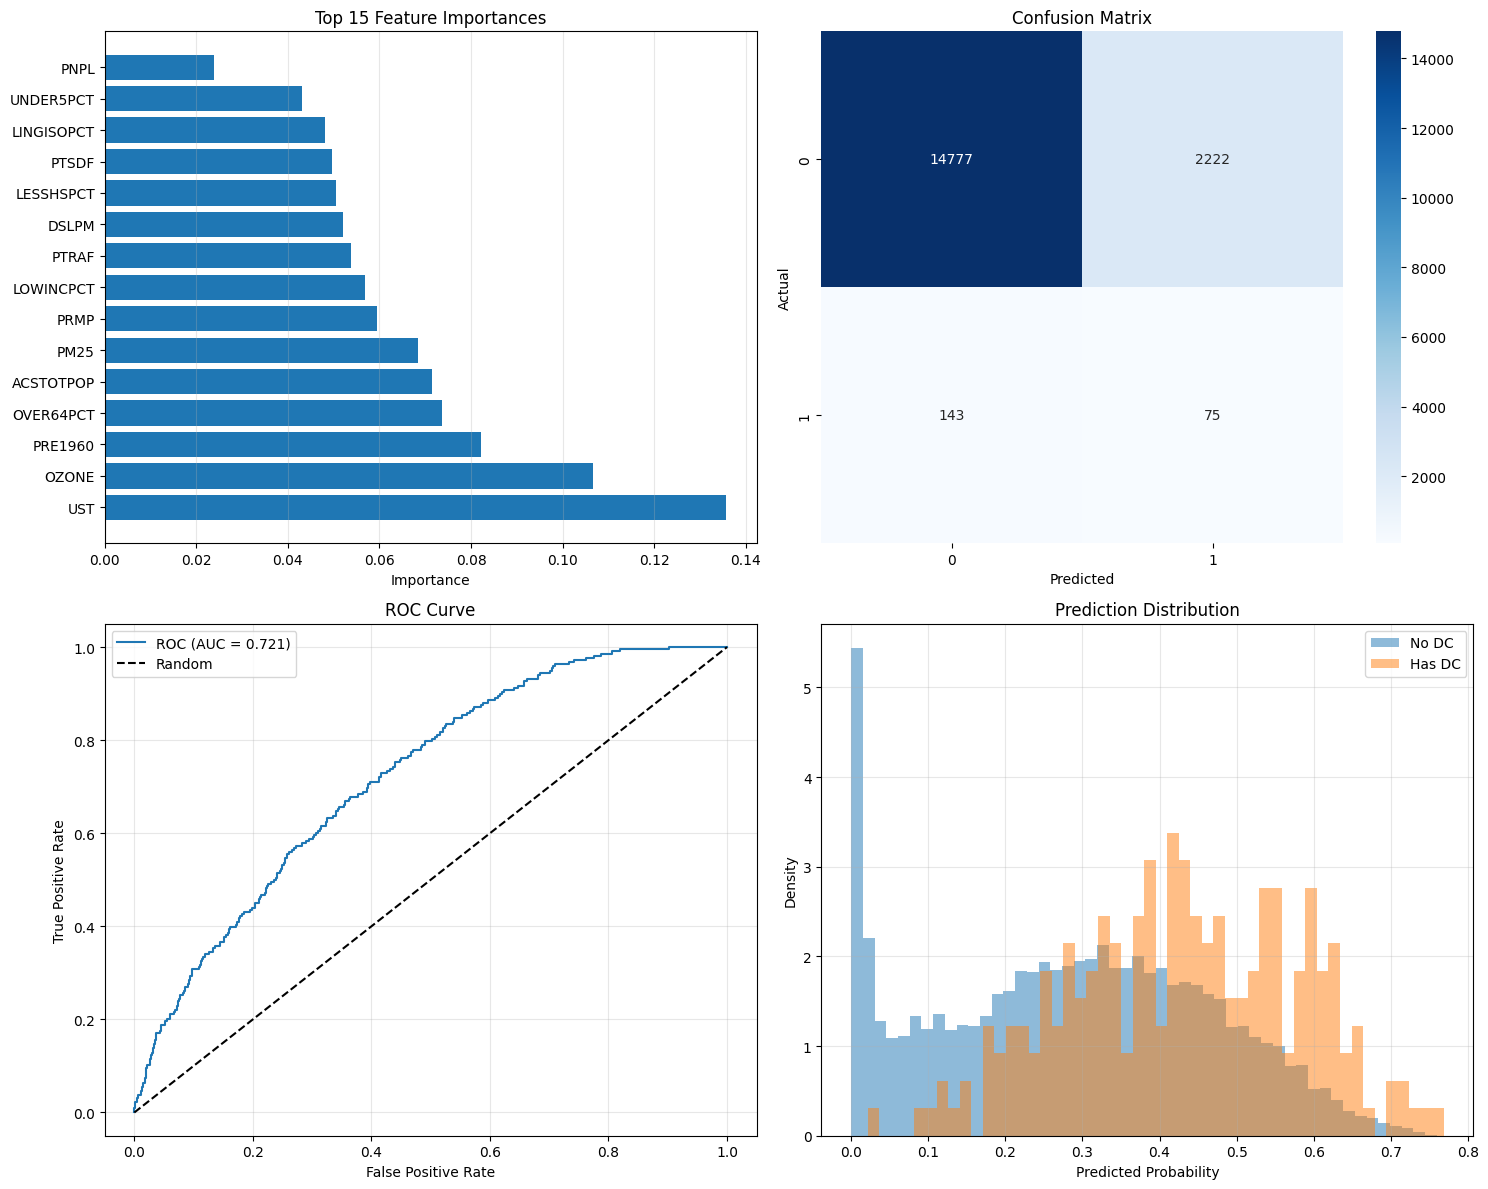

✓ Visualizations saved!


In [44]:
# Cell: Visualize Results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Feature Importance
top_features = feature_importance.head(15)
axes[0, 0].barh(range(len(top_features)), top_features['importance'])
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['feature'])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Top 15 Feature Importances')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_title('Confusion Matrix')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_proba[y_test==0], bins=50, alpha=0.5, label='No DC', density=True)
axes[1, 1].hist(y_pred_proba[y_test==1], bins=50, alpha=0.5, label='Has DC', density=True)
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Prediction Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/zdiener/data-center-classification/notebooks/outputs/random_forest_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved!")

In [45]:
# Cell: Detailed Performance Analysis

print("="*60)
print("INTERPRETING MODEL RESULTS")
print("="*60)

print("\n📊 CLASS IMBALANCE IMPACT:")
print(f"  Negative class (No DC): {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  Positive class (Has DC): {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")
print(f"  Imbalance ratio: {(y_test==0).sum() / (y_test==1).sum():.1f}:1")

print("\n📈 MODEL STRENGTHS:")
print(f"  ✓ ROC-AUC: 0.72 - Good discrimination ability")
print(f"  ✓ Recall for Has DC: 34% - Catches 1 in 3 data centers")
print(f"  ✓ High specificity: Correctly identifies 87% of non-DC tracts")

print("\n⚠️  MODEL CHALLENGES:")
print(f"  • Low precision for Has DC: 3%")
print(f"    (97% of 'Has DC' predictions are false alarms)")
print(f"  • This is expected with 0.01% positive class rate")
print(f"  • Trade-off: To catch 34% of data centers, model flags many non-DC tracts")

print("\n🎯 KEY INSIGHTS:")
print(f"  1. Top predictor: Underground Storage Tanks (UST)")
print(f"  2. Environmental factors matter: Ozone, PM2.5, traffic")
print(f"  3. Demographics: Older population, low income areas")
print(f"  4. Model learned real patterns despite extreme imbalance!")

# Calculate more meaningful metrics
from sklearn.metrics import precision_recall_curve, average_precision_score

print("\n" + "="*60)
print("ADDITIONAL METRICS FOR IMBALANCED DATA")
print("="*60)

# Average Precision (better than ROC-AUC for imbalanced data)
avg_precision = average_precision_score(y_test, y_pred_proba)
print(f"\nAverage Precision Score: {avg_precision:.4f}")
print(f"  (Baseline random: {y_test.sum()/len(y_test):.4f})")
print(f"  Improvement over random: {(avg_precision / (y_test.sum()/len(y_test))):.1f}x")

# Precision-Recall at different thresholds
print("\n📊 Precision-Recall Trade-offs:")
thresholds_to_test = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

for threshold in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"  Threshold {threshold:.3f}: Precision={precision:.3f}, Recall={recall:.3f}, Flags={tp+fp:,} tracts")

INTERPRETING MODEL RESULTS

📊 CLASS IMBALANCE IMPACT:
  Negative class (No DC): 16,999 (98.73%)
  Positive class (Has DC): 218 (1.27%)
  Imbalance ratio: 78.0:1

📈 MODEL STRENGTHS:
  ✓ ROC-AUC: 0.72 - Good discrimination ability
  ✓ Recall for Has DC: 34% - Catches 1 in 3 data centers
  ✓ High specificity: Correctly identifies 87% of non-DC tracts

⚠️  MODEL CHALLENGES:
  • Low precision for Has DC: 3%
    (97% of 'Has DC' predictions are false alarms)
  • This is expected with 0.01% positive class rate
  • Trade-off: To catch 34% of data centers, model flags many non-DC tracts

🎯 KEY INSIGHTS:
  1. Top predictor: Underground Storage Tanks (UST)
  2. Environmental factors matter: Ozone, PM2.5, traffic
  3. Demographics: Older population, low income areas
  4. Model learned real patterns despite extreme imbalance!

ADDITIONAL METRICS FOR IMBALANCED DATA

Average Precision Score: 0.0387
  (Baseline random: 0.0127)
  Improvement over random: 3.1x

📊 Precision-Recall Trade-offs:
  Threshol

In [47]:
# Cell: Analyze What the Model Learned

print("="*60)
print("WHAT MAKES A TRACT LIKELY TO HAVE A DATA CENTER?")
print("="*60)

# Compare feature distributions between DC and non-DC tracts
ml_dataset = pd.read_csv('/Users/zdiener/data-center-classification/data/processed/ml_dataset_random_forest.csv')

print("\nTop 5 Features - Comparing DC vs Non-DC Tracts:\n")

for feature in feature_importance.head(5)['feature']:
    dc_tracts = ml_dataset[ml_dataset['has_datacenter'] == 1][feature]
    no_dc_tracts = ml_dataset[ml_dataset['has_datacenter'] == 0][feature]
    
    print(f"{feature}:")
    print(f"  Tracts WITH DC:    mean={dc_tracts.mean():.4f}, median={dc_tracts.median():.4f}")
    print(f"  Tracts WITHOUT DC: mean={no_dc_tracts.mean():.4f}, median={no_dc_tracts.median():.4f}")
    print(f"  Difference: {((dc_tracts.mean() - no_dc_tracts.mean()) / no_dc_tracts.mean() * 100):.1f}%")
    print()

# Find high-risk tracts
print("="*60)
print("HIGH-RISK TRACTS (Predicted but No Data Center Yet)")
print("="*60)

# Get predictions for full dataset
X_full = ml_dataset[all_features]
X_full_scaled = scaler.transform(X_full)
ml_dataset['predicted_proba'] = rf_model.predict_proba(X_full_scaled)[:, 1]

# High probability but no data center (potential future sites)
high_risk_no_dc = ml_dataset[
    (ml_dataset['has_datacenter'] == 0) & 
    (ml_dataset['predicted_proba'] > 0.05)
].sort_values('predicted_proba', ascending=False)

print(f"\nFound {len(high_risk_no_dc)} high-risk tracts without data centers")
print("\nTop 10 highest risk tracts (potential future locations):")
print(high_risk_no_dc[['census_tract_id', 'predicted_proba'] + feature_importance.head(5)['feature'].tolist()].head(10))

# Save high-risk tracts
high_risk_no_dc.to_csv('/Users/zdiener/data-center-classification/notebooks/outputs/high_risk_tracts.csv', index=False)
print(f"\n✓ High-risk tracts saved")

WHAT MAKES A TRACT LIKELY TO HAVE A DATA CENTER?

Top 5 Features - Comparing DC vs Non-DC Tracts:

UST:
  Tracts WITH DC:    mean=3.6609, median=1.0827
  Tracts WITHOUT DC: mean=3.5524, median=1.0996
  Difference: 3.1%

OZONE:
  Tracts WITH DC:    mean=59.4159, median=58.7924
  Tracts WITHOUT DC: mean=61.8723, median=60.1932
  Difference: -4.0%

PRE1960:
  Tracts WITH DC:    mean=337.4588, median=215.0000
  Tracts WITHOUT DC: mean=438.1828, median=309.0000
  Difference: -23.0%

OVER64PCT:
  Tracts WITH DC:    mean=0.1506, median=0.1492
  Tracts WITHOUT DC: mean=0.1720, median=0.1631
  Difference: -12.4%

ACSTOTPOP:
  Tracts WITH DC:    mean=4398.7573, median=4182.0000
  Tracts WITHOUT DC: mean=3881.6683, median=3726.0000
  Difference: 13.3%

HIGH-RISK TRACTS (Predicted but No Data Center Yet)

Found 73391 high-risk tracts without data centers

Top 10 highest risk tracts (potential future locations):
       census_tract_id  predicted_proba       UST     OZONE  PRE1960  \
43353      2901

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished



✓ High-risk tracts saved


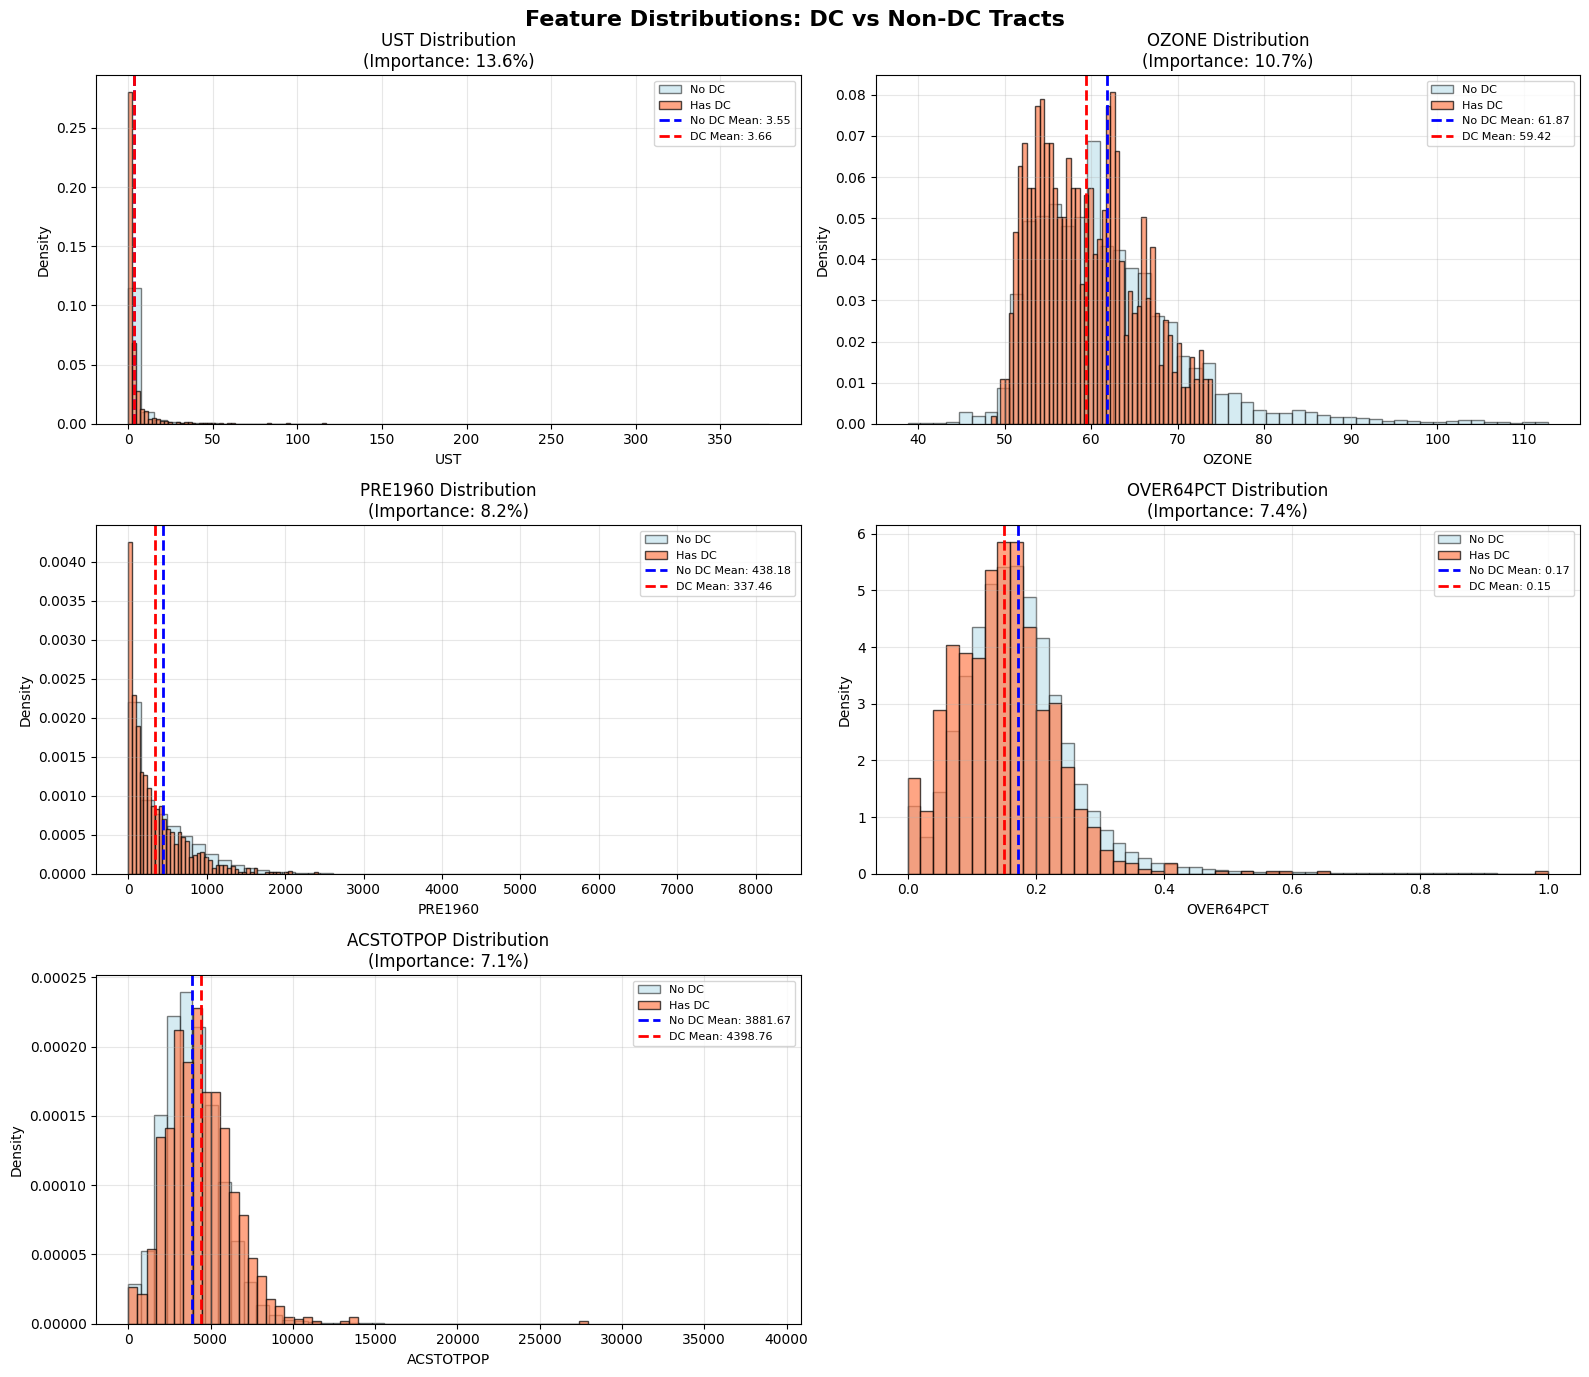

✓ Distribution visualization saved!


In [53]:
# Cell: Visualize Distribution Differences

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

features_to_plot = ['UST', 'OZONE', 'PRE1960', 'OVER64PCT', 'ACSTOTPOP']

for idx, feature in enumerate(features_to_plot):
    dc_tracts = ml_dataset[ml_dataset['has_datacenter'] == 1][feature]
    no_dc_tracts = ml_dataset[ml_dataset['has_datacenter'] == 0][feature]
    
    # Plot distributions
    axes[idx].hist(no_dc_tracts, bins=50, alpha=0.5, label='No DC', 
                   density=True, color='lightblue', edgecolor='black')
    axes[idx].hist(dc_tracts, bins=50, alpha=0.7, label='Has DC', 
                   density=True, color='coral', edgecolor='black')
    
    # Add mean lines
    axes[idx].axvline(no_dc_tracts.mean(), color='blue', linestyle='--', 
                     linewidth=2, label=f'No DC Mean: {no_dc_tracts.mean():.2f}')
    axes[idx].axvline(dc_tracts.mean(), color='red', linestyle='--', 
                     linewidth=2, label=f'DC Mean: {dc_tracts.mean():.2f}')
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{feature} Distribution\n(Importance: {feature_importance[feature_importance["feature"]==feature]["importance"].values[0]:.1%})')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Feature Distributions: DC vs Non-DC Tracts', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/zdiener/data-center-classification/notebooks/outputs/feature_distributions.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution visualization saved!")